In [6]:
import pandas as pd
import numpy as np
import sys
sys.path.append("..")
# from joblib import Parallel, delayed
# from multitaper.mtspec import spectrogram
# from tqdm import tqdm

from multitaper_toolbox.python.multitaper_spectrogram_python import multitaper_spectrogram



from Src.data_modules import *

In [18]:
train_data, train_target = load_train_data()

# Multitaper

Window length   2.0s and overlap 50%
Total number of spectral estimates 8
Frequency band of interest ( 0.00-125.00)Hz
Total frequency points 502
Dimensions de spec : (8,)
Dimensions de time : 502
Dimensions de freq : 502


TypeError: Incompatible X, Y inputs to pcolormesh; see help(pcolormesh)

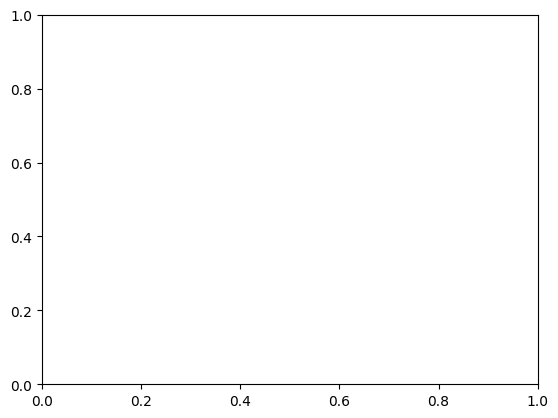

In [11]:
from multitaper.mtspec import spectrogram
import numpy as np
import matplotlib.pyplot as plt

# Signal synthétique
sfreq = 250  # Fréquence d'échantillonnage
duration = 10  # Durée en secondes
t = np.linspace(0, duration, sfreq * duration)
signal = np.sin(2 * np.pi * 10 * t)  # Signal sinusoïdal de 10 Hz

# Calcul multitaper
spec, time, freq, _ = spectrogram(
    signal, 
    dt=1/sfreq, 
    twin=2.0, 
    olap=0.5, 
    nw=3.5, 
    kspec=5
)

# Vérification des dimensions
print("Dimensions de spec :", spec.shape)
print("Dimensions de time :", len(time))
print("Dimensions de freq :", len(freq))

# Reshaping spec si nécessaire pour qu'il ait les dimensions attendues
if spec.ndim == 1:
    spec = np.expand_dims(spec, axis=0)

# Correction pour l'affichage
if spec.ndim == 2:  # S'assurer que spec est bien 2D
    plt.pcolormesh(time, freq, spec.T, shading='auto')  # Utilisez 'auto' pour éviter les erreurs
    plt.colorbar(label='Puissance Spectrale')
    plt.xlabel('Temps (s)')
    plt.ylabel('Fréquence (Hz)')
    plt.title('Multitaper Spectrogram')
    plt.show()
else:
    print("Le spectrogramme n'a pas les dimensions attendues.")


In [4]:
# Simuler des données EEG (par exemple : 5 canaux, 10 secondes de données à 250 Hz)
sampling_rate = 250  # Hz
n_channels = 5
duration = 10  # secondes
n_samples = sampling_rate * duration
#data = np.random.randn(n_channels, n_samples)  # Exemple de données synthétiques

# Paramètres pour la fonction spectrogram
dt = 1 / sampling_rate  # Intervalle de temps entre les échantillons
twin = 1  # Taille des fenêtres en secondes

In [8]:
# Fonction de calcul du spectrogramme pour un canal
def compute_spectrogram(channel_data, dt, twin):
    spec, time, freq, _ = spectrogram(
        channel_data,
        dt=dt,
        twin=twin,
        olap=0.5,
        nw=1,
        kspec=2,
        fmin=5.0,
        fmax=30.0,
        iadapt=0
    )
    return spec, time, freq

# Parallélisation avec affichage de la progression
results = Parallel(n_jobs=-1)(
    delayed(compute_spectrogram)(channel_data, dt, twin) 
    for channel_data in tqdm(train_data, total=n_channels, desc="Traitement des canaux", ncols=100)
)

# Affichage des résultats
for i, (spec, time, freq) in enumerate(results):
    print(f"Spectrogramme du canal {i + 1} :")
    print("Temps :", time)
    print("Fréquences :", freq)
    print("Spectre :", spec)

Traitement des canaux: 100%|██████████████████████████████████████████████████| 5/5 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Exemple de visualisation pour un canal
plt.pcolormesh(time, freq, 10 * np.log10(spec.T), shading='auto')
plt.ylabel('Fréquence (Hz)')
plt.xlabel('Temps (s)')
plt.title('Spectrogramme')
plt.colorbar(label='Puissance (dB)')
plt.show()

NameError: name 'time' is not defined

# Multitaper_toolbox

In [ ]:
# Paramètres du spectrogramme
fs = 250  # Fréquence d'échantillonnage
frequency_range = [5, 50]  # Limite des fréquences entre 5 et 50 Hz
time_bandwidth = 3  # Bande passante temporelle
num_tapers = 7  # Nombre de tapers (meilleur est time_bandwidth*2 - 1)
window_params = [2, 1]  # Taille de la fenêtre de 2s avec un pas de 0s
min_nfft = 0  # Pas de minimum nfft
detrend_opt = 'constant'  # Detrend chaque fenêtre en soustrayant la moyenne
multiprocess = True  # Utilisation de multiprocessing
n_jobs = 3  # Utilisation de 3 cœurs en multiprocessing
weighting = 'unity'  # Poids des tapers égaux à 1
plot_on = True  # Affichage du spectrogramme
return_fig = False  # Ne pas retourner le graphique
clim_scale = False  # Ne pas appliquer l'auto-scaling du colormap
verbose = True  # Affichage d'informations supplémentaires
xyflip = False  # Ne pas transposer la matrice de sortie du spectrogramme

# Générer un exemple de signal train_data avec 5 canaux et 250 Hz de fréquence d'échantillonnage
# train_data est une matrice de forme (temps, canaux), ici pour l'exemple nous générons un signal simple.
# Remplacez par vos données réelles (train_data)
duration = 10  # Durée en secondes (10 secondes pour cet exemple)
t = np.linspace(0, duration, fs * duration)

# Nous voulons afficher 3 fenêtres de 2 secondes
window_duration = 500  # exemple de durée de fenêtre
start_times = np.arange(0, len(train_data[0]) - window_duration, window_duration)  # Par exemple, 500 échantillons

# Calculer le spectrogramme multitaper pour chaque fenêtre
for start_time in start_times:
    window_data = train_data[int(start_time * fs):int((start_time + window_duration) * fs), :]  # Extraire la fenêtre de données
    print(f"Shape of extracted window data: {window_data.shape}")
    spect, stimes, sfreqs = multitaper_spectrogram(
        window_data.flatten(),  # Aplatir les données pour les 5 canaux (mettre les données dans un seul vecteur)
        fs,
        frequency_range,
        time_bandwidth,
        num_tapers,
        window_params,
        min_nfft,
        detrend_opt,
        multiprocess,
        n_jobs,
        weighting,
        plot_on,
        return_fig,
        clim_scale,
        verbose,
        xyflip
    )

    # Affichage du spectrogramme
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(stimes, sfreqs, spect, shading='auto')
    plt.colorbar(label='Puissance Spectrale')
    plt.title(f'Spectrogramme Multitaper - Fenêtre de Temps {start_time}s à {start_time + window_duration}s')
    plt.xlabel('Temps (s)')
    plt.ylabel('Fréquence (Hz)')
    plt.ylim([5, 50])  # Limiter les fréquences de 5 à 50 Hz
    plt.show()


In [20]:
# Paramètres du spectrogramme
fs = 250  # Fréquence d'échantillonnage
frequency_range = [5, 50]  # Limite des fréquences entre 5 et 50 Hz
time_bandwidth = 3  # Bande passante temporelle
num_tapers = 7  # Nombre de tapers (meilleur est time_bandwidth*2 - 1)
window_params = [2, 1]  # Taille de la fenêtre de 2s avec un pas de 1s
min_nfft = 0  # Pas de minimum nfft
detrend_opt = 'constant'  # Detrend chaque fenêtre en soustrayant la moyenne
multiprocess = True  # Utilisation de multiprocessing
n_jobs = 3  # Utilisation de 3 cœurs en multiprocessing
weighting = 'unity'  # Poids des tapers égaux à 1
plot_on = True  # Affichage du spectrogramme
return_fig = False  # Ne pas retourner le graphique
clim_scale = False  # Ne pas appliquer l'auto-scaling du colormap
verbose = True  # Affichage d'informations supplémentaires
xyflip = False  # Ne pas transposer la matrice de sortie du spectrogramme

# Générer un exemple de signal train_data avec 5 canaux et 250 Hz de fréquence d'échantillonnage
# Remplacez par vos données réelles (train_data)
duration = 10  # Durée en secondes (10 secondes pour cet exemple)
t = np.linspace(0, duration, fs * duration)

# Durée de la fenêtre (en échantillons)
window_duration = 500  # 2 secondes à 250 Hz
window_step = 250  # Pas de 1 seconde

# Calcul des start_times pour extraire des fenêtres successives
start_times = np.arange(0, len(train_data) - window_duration, window_step)  # 500 échantillons pour chaque fenêtre de 2 secondes

# Vérification de la longueur de chaque fenêtre extraite et calcul du spectrogramme multitaper
for start_time in start_times:
    start_idx = int(start_time)
    end_idx = start_idx + window_duration  # Indice de fin de la fenêtre
    
    # Vérifiez que vous ne dépassez pas la longueur des données
    if end_idx <= len(train_data):
        window_data = train_data[start_idx:end_idx, :]  # Extraire la fenêtre
        print(f"Shape of extracted window data: {window_data.shape}")
        
        # Calcul du spectrogramme multitaper pour la fenêtre extraite
        spect, stimes, sfreqs = multitaper_spectrogram(
            window_data.flatten(),  # Aplatir les données pour les 5 canaux (mettre les données dans un seul vecteur)
            fs,
            frequency_range,
            time_bandwidth,
            num_tapers,
            window_params,
            min_nfft,
            detrend_opt,
            multiprocess,
            n_jobs,
            weighting,
            plot_on,
            return_fig,
            clim_scale,
            verbose,
            xyflip
        )

        # Affichage du spectrogramme
        plt.figure(figsize=(10, 6))
        plt.pcolormesh(stimes, sfreqs, spect, shading='auto')
        plt.colorbar(label='Puissance Spectrale')
        plt.title(f'Spectrogramme Multitaper - Fenêtre de Temps {start_time/fs:.2f}s à {(start_time + window_duration)/fs:.2f}s')
        plt.xlabel('Temps (s)')
        plt.ylabel('Fréquence (Hz)')
        plt.ylim(frequency_range)  # Limiter les fréquences de 5 à 50 Hz
        plt.show()
    else:
        print(f"Fenêtre {start_time/fs:.2f}s à {(start_time + window_duration)/fs:.2f}s dépasse la longueur des données.")


In [21]:
# Paramètres du spectrogramme
fs = 250  # Fréquence d'échantillonnage
frequency_range = [5, 50]  # Limite des fréquences entre 5 et 50 Hz
time_bandwidth = 3  # Bande passante temporelle
num_tapers = 7  # Nombre de tapers (meilleur est time_bandwidth*2 - 1)
window_params = [2, 1]  # Taille de la fenêtre de 2s avec un pas de 1s
min_nfft = 0  # Pas de minimum nfft
detrend_opt = 'constant'  # Detrend chaque fenêtre en soustrayant la moyenne
multiprocess = True  # Utilisation de multiprocessing
n_jobs = 3  # Utilisation de 3 cœurs en multiprocessing
weighting = 'unity'  # Poids des tapers égaux à 1
plot_on = False  # Ne pas afficher chaque spectrogramme individuellement
return_fig = False  # Ne pas retourner le graphique
clim_scale = False  # Ne pas appliquer l'auto-scaling du colormap
verbose = True  # Affichage d'informations supplémentaires
xyflip = False  # Ne pas transposer la matrice de sortie du spectrogramme

# Générer un exemple de signal train_data avec 5 canaux et 250 Hz de fréquence d'échantillonnage
# Remplacez par vos données réelles (train_data)
duration = 10  # Durée en secondes (10 secondes pour cet exemple)
t = np.linspace(0, duration, fs * duration)

# Durée de la fenêtre (en échantillons)
window_duration = 500  # 2 secondes à 250 Hz
window_step = 250  # Pas de 1 seconde

# Calcul des start_times pour extraire des fenêtres successives
start_times = np.arange(0, len(train_data) - window_duration, window_step)  # 500 échantillons pour chaque fenêtre de 2 secondes

# Variables pour stocker tous les spectrogrammes
spectrograms = []

# Calcul des spectrogrammes pour chaque fenêtre
for start_time in start_times:
    start_idx = int(start_time)
    end_idx = start_idx + window_duration  # Indice de fin de la fenêtre
    
    # Vérifiez que vous ne dépassez pas la longueur des données
    if end_idx <= len(train_data):
        window_data = train_data[start_idx:end_idx, :]  # Extraire la fenêtre
        print(f"Shape of extracted window data: {window_data.shape}")
        
        # Calcul du spectrogramme multitaper pour la fenêtre extraite
        spect, stimes, sfreqs = multitaper_spectrogram(
            window_data.flatten(),  # Aplatir les données pour les 5 canaux (mettre les données dans un seul vecteur)
            fs,
            frequency_range,
            time_bandwidth,
            num_tapers,
            window_params,
            min_nfft,
            detrend_opt,
            multiprocess,
            n_jobs,
            weighting,
            plot_on,
            return_fig,
            clim_scale,
            verbose,
            xyflip
        )

        # Ajouter le spectrogramme à la liste
        spectrograms.append(spect)

# Combiner tous les spectrogrammes en un seul
combined_spectrogram = np.concatenate(spectrograms, axis=1)

# Affichage du spectrogramme combiné
plt.figure(figsize=(10, 6))
plt.pcolormesh(stimes, sfreqs, combined_spectrogram, shading='auto')
plt.colorbar(label='Puissance Spectrale')
plt.title('Spectrogramme Multitaper Combiné')
plt.xlabel('Temps (s)')
plt.ylabel('Fréquence (Hz)')
plt.ylim(frequency_range)  # Limiter les fréquences de 5 à 50 Hz
plt.show()


ValueError: need at least one array to concatenate